In [4]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys
import cmocean

warnings.filterwarnings("ignore")
sys.path.append('../src')
sys.path.append('../src-double-gyre')
from plot_helpers import create_animation_ffmpeg, default_rcParams

%load_ext autoreload
%autoreload 3

# Double Gyre

In [ ]:
from helpers.collection_of_experiments import CollectionOfExperiments

In [ ]:
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/filtered', additional_subfolder='output')

In [ ]:
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [ ]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/generalization', additional_subfolder='output')

CPU times: user 48.6 ms, sys: 132 ms, total: 180 ms
Wall time: 5.25 s


In [ ]:
%time ds +=  CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_gprime_2', additional_subfolder='output', prefix='R2_FGR3_gprime_2')

CPU times: user 65.1 ms, sys: 427 ms, total: 492 ms
Wall time: 16.9 s


In [ ]:
from helpers.computational_tools import Lk_error
def plot_ssh(self, exps, labels=None, target=None, ncols=3, zi=0, vmax=2.0, cmap='RdBu_r', clabel=True, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels_field = np.arange(-vmax,vmax+0.5,0.5)
        levels_bias = np.arange(-2,2.2,0.2)
    else:
        levels_field = np.arange(-1400,-550,50)
        levels_bias = np.arange(-100,110,10)

    
    plt.figure(figsize=(20,6))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh = self[exp].e_mean.isel(zi=zi)
        levels = levels_field
        label = 'SSH [m]'
        lines = True
        im = ssh.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=False)
        if lines:
            Cplot = ssh.plot.contour(levels=levels, colors='k', linewidths=1)
            if clabel:
                plt.gca().clabel(Cplot, Cplot.levels)
        plt.xticks(())
        plt.yticks((30, 35, 40, 45, 50))
        plt.xlabel('')
        plt.ylabel('Latitude')
        plt.title(labels[ifig])

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].e_mean.isel(zi=zi),self[exps[-1]].e_mean.isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].e_mean.isel(zi=zi),self[exps[-1]].e_mean.isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(11,33,'RMSE='+str(round(RMSE,3))+'m', fontsize=16)
                plt.text(11,31,'corr='+str(round(corr,3)), fontsize=16)
        plt.gca().set_aspect(1)

    cbar = plt.colorbar(im, ax = plt.gcf().axes, shrink=0.7, pad=0.01)
    cbar.set_label('Time-averaged \nSea Surface Height (SSH) [m]', fontsize=18)

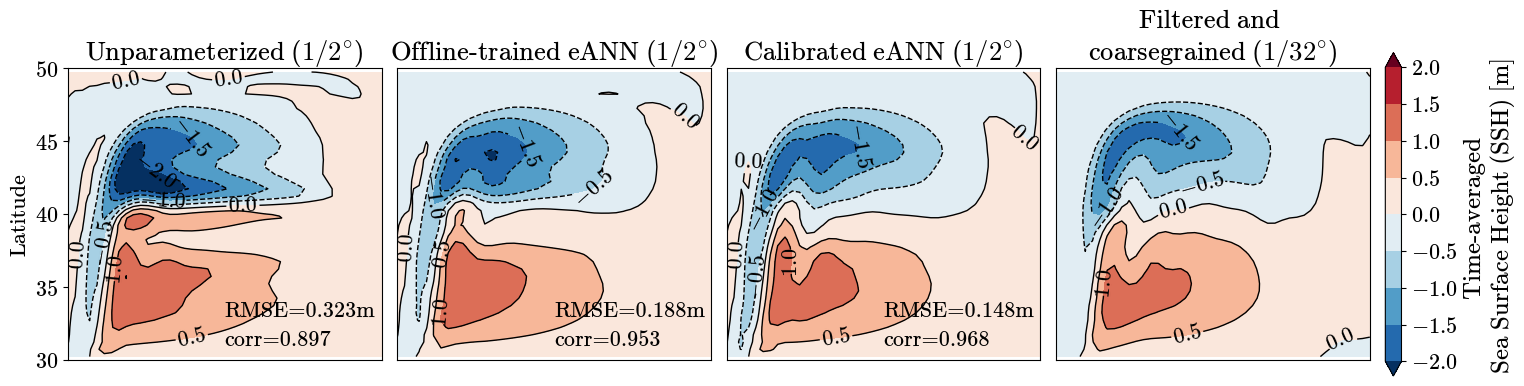

In [ ]:
default_rcParams({'font.size': 16})
plot_ssh(ds, ['R2-100-years', 'eANN-scaling-1.4', 'R2_FGR3_gprime_2-iteration-05-ens-member-100-100years', 'R32_R2_FGR3'],
        ['Unparameterized ($1/2^{\circ}$)', 'Offline-trained eANN ($1/2^{\circ}$)', 'Calibrated eANN ($1/2^{\circ}$)', 'Filtered and \ncoarsegrained ($1/32^{\circ}$)'], ncols=4)
for j in range(2,5):
    plt.subplot(1,4,j)
    plt.ylabel('')
    plt.yticks([])
plt.savefig('paper_figures/figure2-mean-review.pdf')

In [ ]:
def plot_ssh_std(self, exps, labels=None, target=None, ncols=3, zi=0, vmax=3.0, cmap=cmocean.cm.amp, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels = np.arange(0,0.65,0.05)
    else:
        levels = np.arange(0,65,5)

    
    plt.figure(figsize=(20,6))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh_std = self[exp].e_std.isel(zi=zi)
        im = ssh_std.plot.contourf(levels=levels, cmap=cmap, extend='both', add_colorbar=False)
        plt.xticks((0,5,10,15,20))
        plt.yticks((30, 35, 40, 45, 50))
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title(labels[ifig])

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].e_std.isel(zi=zi),self[exps[-1]].e_std.isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].e_std.isel(zi=zi),self[exps[-1]].e_std.isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(11,33,'RMSE='+str(round(RMSE,3))+'m', fontsize=16, color='k')
                plt.text(11,31,'corr='+str(round(corr,3)), fontsize=16, color='k')
        plt.gca().set_aspect(1)

    cbar = plt.colorbar(im, ax = plt.gcf().axes, shrink=0.7, pad=0.01)
    cbar.set_label('Temporal STD of SSH [m]', fontsize=18)

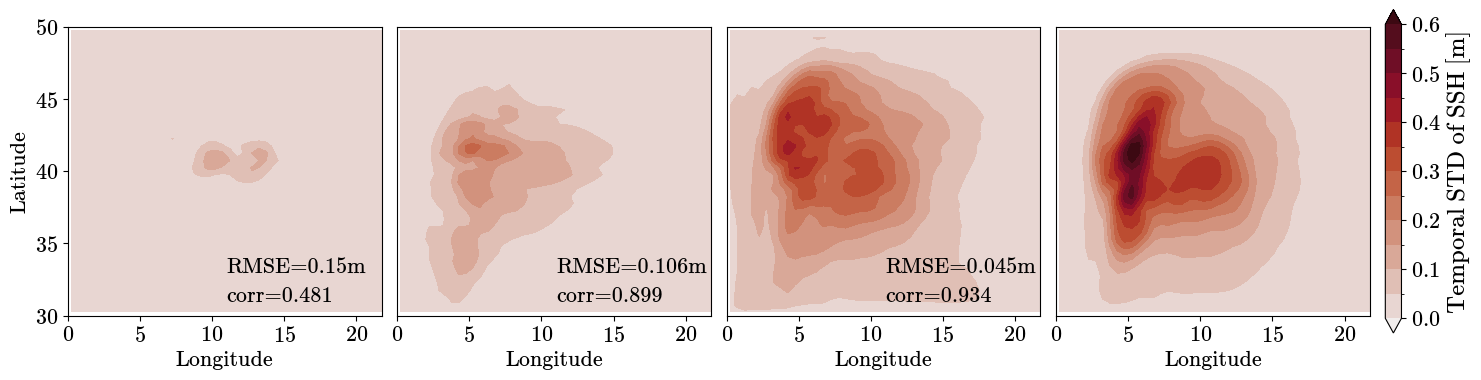

In [ ]:
default_rcParams({'font.size': 16})
plot_ssh_std(ds, ['R2-100-years', 'eANN-scaling-1.4', 'R2_FGR3_gprime_2-iteration-05-ens-member-100-100years', 'R32_R2_FGR3'],
        ['']*4, ncols=4)
for j in range(2,5):
    plt.subplot(1,4,j)
    plt.ylabel('')
    plt.yticks([])
plt.savefig('paper_figures/figure2-std-review.pdf')

In [ ]:
RMSE_ssh = []
RMSE_ssh_std = []
corr_ssh = []
corr_ssh_std = []
gamma = [0, 0.25, 0.5, 0.75, 1.0, 1.1, 1.2, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.8, 1.9, 2.0, 2.5, 3.0]

ssh_true = ds['R32_R2_FGR3'].e_mean.isel(zi=0)
ssh_std_true = ds['R32_R2_FGR3'].e_std.isel(zi=0)
for exp in ['R2-100-years', 'eANN-scaling-0.25', 'eANN-scaling-0.5', 'eANN-scaling-0.75', 
               'eANN-scaling-1.0', 'eANN-scaling-1.1', 'eANN-scaling-1.2', 'eANN-scaling-1.3',
               'eANN-scaling-1.35', 'eANN-scaling-1.4', 'eANN-scaling-1.45', 'eANN-scaling-1.5',
               'eANN-scaling-1.55', 'eANN-scaling-1.6', 'eANN-scaling-1.65', 'eANN-scaling-1.7',
               'eANN-scaling-1.8', 'eANN-scaling-1.9', 'eANN-scaling-2.0', 'eANN-scaling-2.5',
               'eANN-scaling-3.0']:
    ssh = ds[exp].e_mean.isel(zi=0)
    ssh_std = ds[exp].e_std.isel(zi=0)

    RMSE_ssh.append(Lk_error(ssh, ssh_true)[0])
    RMSE_ssh_std.append(Lk_error(ssh_std, ssh_std_true)[0])
    corr_ssh.append(float(xr.corr(ssh, ssh_true)))
    corr_ssh_std.append(float(xr.corr(ssh_std, ssh_std_true)))

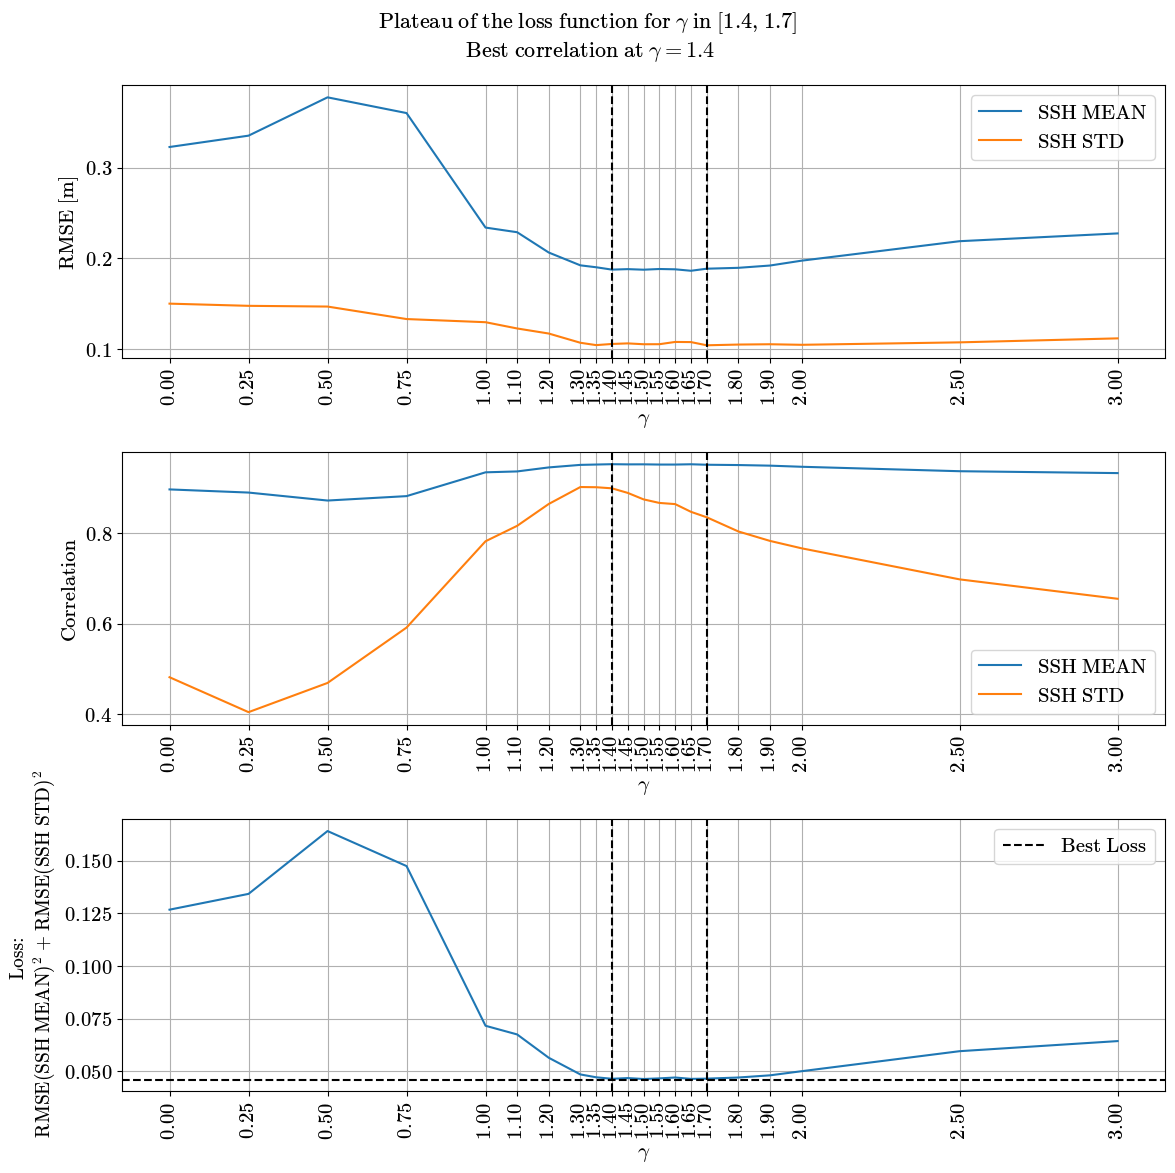

In [ ]:
default_rcParams({'font.size': 15})
plt.figure(figsize=(12,12))

plt.subplot(3,1,1)
plt.plot(gamma, RMSE_ssh, label='SSH MEAN')
plt.plot(gamma, RMSE_ssh_std, label='SSH STD')
plt.ylabel('RMSE [m]')
plt.xlabel('$\gamma$')
plt.xticks(gamma, rotation=90)
plt.axvline(x=1.4, color='k', linestyle='--')
plt.axvline(x=1.7, color='k', linestyle='--')
plt.legend()
plt.grid()

plt.subplot(3,1,2)
plt.plot(gamma, corr_ssh, label='SSH MEAN')
plt.plot(gamma, corr_ssh_std, label='SSH STD')
plt.ylabel('Correlation')
plt.xlabel('$\gamma$')
plt.xticks(gamma, rotation=90)
plt.axvline(x=1.4, color='k', linestyle='--')
plt.axvline(x=1.7, color='k', linestyle='--')
plt.legend()
plt.grid()

plt.subplot(3,1,3)
plt.plot(gamma, np.array(RMSE_ssh)**2 + np.array(RMSE_ssh_std)**2)
plt.ylabel('Loss: \n RMSE(SSH MEAN)$^2$ + RMSE(SSH STD)$^2$', fontsize=14)
plt.xlabel('$\gamma$')
plt.xticks(gamma, rotation=90)
plt.grid()
plt.axhline(y=0.046, color='k', linestyle='--', label='Best Loss')
plt.axvline(x=1.4, color='k', linestyle='--')
plt.axvline(x=1.7, color='k', linestyle='--')

plt.legend()

plt.suptitle('Plateau of the loss function for $\gamma$ in [1.4, 1.7]\n Best correlation at $\gamma=1.4$', fontsize=16)

plt.tight_layout()
plt.savefig('paper_figures/Optimal_gamma_DG.pdf', bbox_inches='tight')

# Convergence of metrics

In [ ]:
dd = {}
for exp in ['R2_FGR3_gprime_2', 'R2_FGR3_gprime_2_rng', 'R2_FGR3_gprime_2_rng2', 'R2_FGR3_gprime', 'R2_FGR3_gprime_5', 'R2_FGR3_gprime_0.1', 'one_parameter']:
    print(exp)
    try:
        dd[exp] = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/{exp}/recompute_metrics/metrics*')
    except:
        dd[exp] = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/{exp}/metrics*')

R2_FGR3_gprime_2
R2_FGR3_gprime_2_rng
R2_FGR3_gprime_2_rng2
R2_FGR3_gprime
R2_FGR3_gprime_5
R2_FGR3_gprime_0.1
one_parameter


In [ ]:
def plot_metrics(exp='R2_FGR3_gprime_2', color='tab:blue', alpha=1.0):

    # Here we rescale RMSE so we account for upper and lower interfaces together
    npoints = 40 * 44 * 2
    metrics = dd[exp]
    e_mean_rmse = np.sqrt(metrics.e_mean_WSE.sum('zi', skipna=False) / npoints)
    e_std_rmse = np.sqrt(metrics.e_std_WSE.sum('zi', skipna=False) / npoints)
    param_cov_trace = metrics.param.var('ens').sum('pdim')
    e_3rd_rmse = np.sqrt(metrics.e_3rd_WSE.sum('zi', skipna=False) / npoints)
    e_4th_rmse = np.sqrt(metrics.e_4th_WSE.sum('zi', skipna=False) / npoints)

    plt.subplot(1,3,1)
    data = e_mean_rmse.copy()
    mean = data.median('ens')
    q25  = data.quantile(0.25, 'ens')
    q75  = data.quantile(0.75, 'ens')
    lower = mean - q25
    upper = q75 - mean
    yerr = np.vstack([lower.values, upper.values])
    x = mean.iter
    plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color=color, ls='-', alpha=alpha)
    plt.ylim([0, 0.3])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.yticks(np.arange(0,0.35,0.05));
    plt.title('Mean Interfaces')
    plt.ylabel('RMSE in $\eta$ [m]')
    plt.xlabel('Iteration')

    plt.subplot(1,3,2)
    data = e_std_rmse.copy()
    mean = data.median('ens')
    q25  = data.quantile(0.25, 'ens')
    q75  = data.quantile(0.75, 'ens')
    lower = mean - q25
    upper = q75 - mean
    yerr = np.vstack([lower.values, upper.values])
    x = mean.iter
    plt.errorbar(x, mean, yerr=yerr, fmt='o', capsize=4, color=color, ls='-', alpha=alpha)
    plt.ylim([0, 0.15])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.yticks(np.arange(0,0.175,0.025));
    plt.title('STD of Interfaces')
    plt.ylabel('RMSE in $\\sqrt{\\overline{\\eta\'^2}^t}$ [m]')
    plt.xlabel('Iteration')

    plt.subplot(1,3,3)
    data = param_cov_trace.copy()
    x = data.iter
    plt.plot(x, data, 'o-', color=color, alpha=alpha)
    plt.xticks(np.arange(10))
    plt.grid()
    plt.ylim([0,0.5])
    plt.yticks(np.arange(0,0.55,0.05));
    plt.title('Ensemble Spread')
    plt.ylabel('$\\mathrm{tr}\\,\\mathrm{Cov}(\\mathbf{\\theta})$')
    plt.xlabel('Iteration')

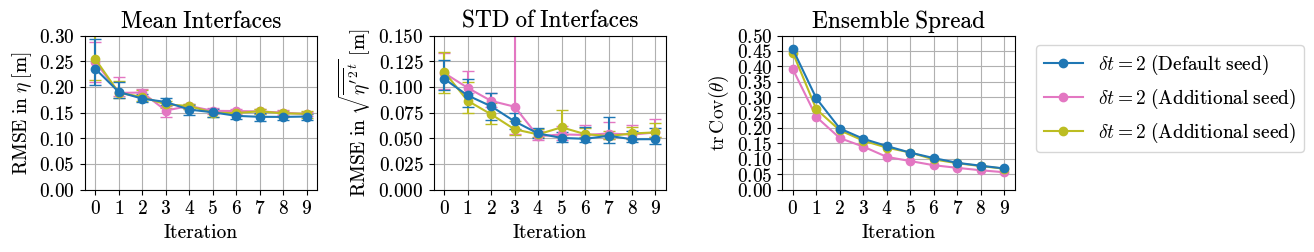

In [ ]:
default_rcParams()
plt.figure(figsize=(12,2))
plt.subplots_adjust(hspace=0.05, wspace=0.5)

plot_metrics('R2_FGR3_gprime_2_rng', 'tab:pink')
plot_metrics('R2_FGR3_gprime_2_rng2', 'tab:olive')
plot_metrics('R2_FGR3_gprime_2', 'tab:blue')
plt.plot([], [], 'o-', color='tab:blue', label='$\delta t=2$ (Default seed)')
plt.plot([], [], 'o-', color='tab:pink', label='$\delta t=2$ (Additional seed)')
plt.plot([], [], 'o-', color='tab:olive', label='$\delta t=2$ (Additional seed)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('paper_figures/rng_spread.pdf')

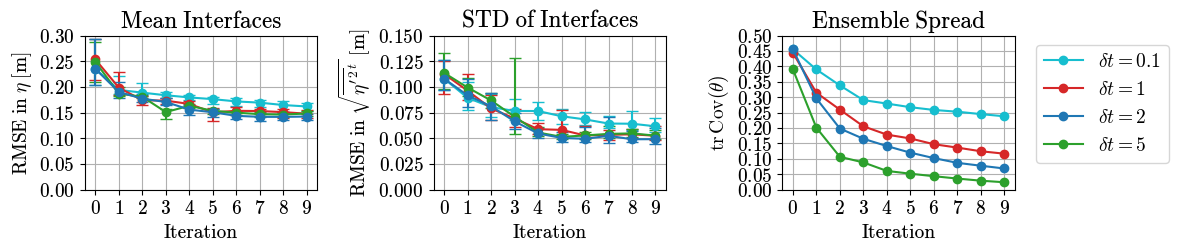

In [ ]:
default_rcParams()
plt.figure(figsize=(12,2))
plt.subplots_adjust(hspace=0.05, wspace=0.5)

plot_metrics('R2_FGR3_gprime_0.1', 'tab:cyan', alpha=1.0)
plot_metrics('R2_FGR3_gprime', 'tab:red', alpha=1.0)
plot_metrics('R2_FGR3_gprime_5', 'tab:green', alpha=1.0)
plot_metrics('R2_FGR3_gprime_2', 'tab:blue', alpha=1.0)
plt.plot([], [], 'o-', color='tab:cyan', label='$\delta t=0.1$')
plt.plot([], [], 'o-', color='tab:red', label='$\delta t=1$')
plt.plot([], [], 'o-', color='tab:blue', label='$\delta t=2$')
plt.plot([], [], 'o-', color='tab:green', label='$\delta t=5$')
for j in range(1,4):
    plt.subplot(1,3,j)
    plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('paper_figures/scheduler_step.pdf')

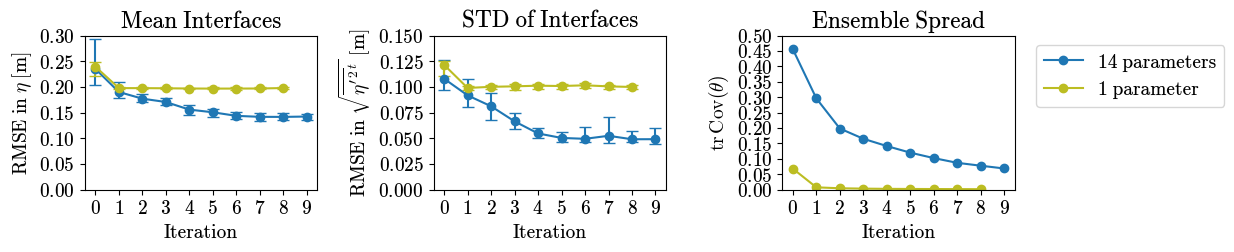

In [ ]:
default_rcParams()
plt.figure(figsize=(12,2))
plt.subplots_adjust(hspace=0.05, wspace=0.5)

plot_metrics('R2_FGR3_gprime_2', 'tab:blue')
plot_metrics('one_parameter', 'tab:olive')
plt.plot([], [], 'o-', color='tab:blue', label='14 parameters')
plt.plot([], [], 'o-', color='tab:olive', label='1 parameter')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('paper_figures/1_vs_14_parameters.pdf')

# Show mean and std for NW2

In [ ]:
unparameterized = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/Control/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-ANN/eANN-noncalibrated/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline_1p25 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-offline-1.25-boundary/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline_1p0 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-offline-1.0/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline_0p75 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-offline-0.75/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline_0p5 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-offline-0.5/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_offline_0p25 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-offline-0.25/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_DG = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-gprime_2-DG-0.65/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_DG_0p7 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-gprime_2-DG-0.7/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_DG_0p6 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-gprime_2-DG-0.6/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_DG_0p5 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-gprime_2-DG-0.5/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_NW2 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-NW2-gprime_n-it3-ens-200-default/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_NW2_800 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-NW2-day-0-ave-800/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
eANN_NW2_1100 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/eANN-NW2-day-1000-ave-100/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
Yankovsky24 = xr.open_mfdataset('/scratch/pp2681/mom6/Neverworld2/simulations/R2-long-new/Yankovsky24-1.0/output/snapshots_00029005.nc', decode_times=False).isel(time=slice(-160,None))
truth = xr.open_dataset('/home/pp2681/calibration/scripts/R32_R2_FGR3_NW2/800days_v3.nc')

In [ ]:
mask_nan = eANN_offline.e.isel(time=-1)*0 + 1

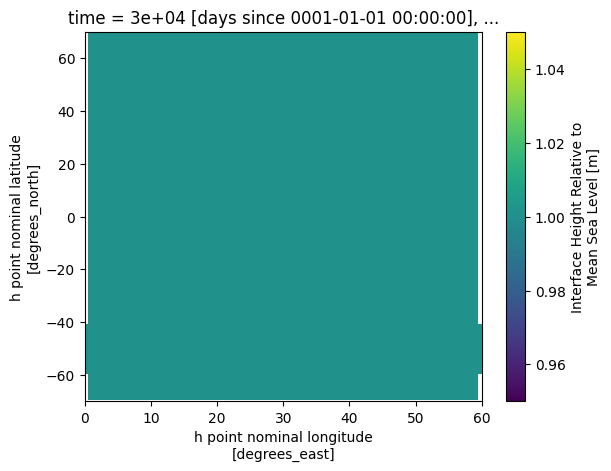

In [ ]:
mask_nan[0].plot()

In [ ]:
std_dict = {
    'unparameterized': unparameterized.e.std('time').compute(),
    'eANN_offline': eANN_offline.e.std('time').compute(),
    'eANN_offline_1p25': eANN_offline_1p25.e.std('time').compute(),
    'eANN_offline_1p0': eANN_offline_1p0.e.std('time').compute(),
    'eANN_offline_0p75': eANN_offline_0p75.e.std('time').compute(),
    'eANN_offline_0p5': eANN_offline_0p5.e.std('time').compute(),
    'eANN_offline_0p25': eANN_offline_0p25.e.std('time').compute(),
    'eANN_DG': eANN_DG.e.std('time').compute(),
    'eANN_DG_0.7': eANN_DG_0p7.e.std('time').compute(),
    'eANN_DG_0.6': eANN_DG_0p6.e.std('time').compute(),
    'eANN_DG_0.5': eANN_DG_0p5.e.std('time').compute(),
    'eANN_NW2': eANN_NW2.e.std('time').compute(),
    'eANN_NW2_800': eANN_NW2_800.e.std('time').compute(),
    'eANN_NW2_1100': eANN_NW2_1100.e.std('time').compute(),
    'Yankovsky24': Yankovsky24.e.std('time').compute(),
    'truth': (mask_nan*truth.e_std).compute()
}

In [ ]:
mean_dict = {
    'unparameterized': unparameterized.e.mean('time').compute(),
    'eANN_offline': eANN_offline.e.mean('time').compute(),
    'eANN_offline_1p25': eANN_offline_1p25.e.mean('time').compute(),
    'eANN_offline_1p0': eANN_offline_1p0.e.mean('time').compute(),
    'eANN_offline_0p75': eANN_offline_0p75.e.mean('time').compute(),
    'eANN_offline_0p5': eANN_offline_0p5.e.mean('time').compute(),
    'eANN_offline_0p25': eANN_offline_0p25.e.mean('time').compute(),
    'eANN_DG': eANN_DG.e.mean('time').compute(),
    'eANN_DG_0.7': eANN_DG_0p7.e.mean('time').compute(),
    'eANN_DG_0.6': eANN_DG_0p6.e.mean('time').compute(),
    'eANN_DG_0.5': eANN_DG_0p5.e.mean('time').compute(),
    'eANN_NW2': eANN_NW2.e.mean('time').compute(),
    'eANN_NW2_800': eANN_NW2_800.e.mean('time').compute(),
    'eANN_NW2_1100': eANN_NW2_1100.e.mean('time').compute(),
    'Yankovsky24': Yankovsky24.e.mean('time').compute(),
    'truth': (mask_nan*truth.e_mean).compute()
}

In [ ]:
interface_dict = {
    'unparameterized': unparameterized.e.mean('xh').mean('time').compute(),
    'eANN_offline': eANN_offline.e.mean('xh').mean('time').compute(),
    'eANN_offline_1p25': eANN_offline_1p25.e.mean('xh').mean('time').compute(),
    'eANN_offline_1p0': eANN_offline_1p0.e.mean('xh').mean('time').compute(),
    'eANN_offline_0p75': eANN_offline_0p75.e.mean('xh').mean('time').compute(),
    'eANN_offline_0p5': eANN_offline_0p5.e.mean('xh').mean('time').compute(),
    'eANN_offline_0p25': eANN_offline_0p25.e.mean('xh').mean('time').compute(),
    'eANN_DG': eANN_DG.e.mean('xh').mean('time').compute(),
    'eANN_DG_0.7': eANN_DG_0p7.e.mean('xh').mean('time').compute(),
    'eANN_DG_0.6': eANN_DG_0p6.e.mean('xh').mean('time').compute(),
    'eANN_DG_0.5': eANN_DG_0p5.e.mean('xh').mean('time').compute(),
    'eANN_NW2': eANN_NW2.e.mean('xh').mean('time').compute(),
    'eANN_NW2_800': eANN_NW2_800.e.mean('xh').mean('time').compute(),
    'eANN_NW2_1100': eANN_NW2_1100.e.mean('xh').mean('time').compute(),
    'Yankovsky24': Yankovsky24.e.mean('xh').mean('time').compute(),
    'truth': (mask_nan*truth.e_mean).mean('xh').compute()
}

In [ ]:
from helpers.computational_tools import Lk_error
def plot_ssh(self, exps, labels=None, target=None, ncols=6, zi=0, vmax=4.0, cmap='RdBu_r', clabel=True, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels_field = np.arange(-vmax,vmax+0.5,0.5)
        levels_bias = np.arange(-2,2.2,0.2)
    else:
        levels_field = 10
        levels_bias = np.arange(-100,110,10)

    
    plt.figure(figsize=(15,6))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh = self[exp].isel(zi=zi)
        levels = levels_field
        label = 'SSH [m]'
        lines = True
        im = ssh.plot.contourf(levels=levels, cmap=cmap, linewidths=1, extend='both', add_colorbar=False, robust=True)
        #plt.xticks(())
        #plt.yticks((30, 35, 40, 45, 50))
        #plt.xlabel('')
        plt.ylabel('')
        plt.title(labels[ifig])

        if exp != exps[-1]:
            RMSE = Lk_error(self[exp].isel(zi=zi),self[exps[-1]].isel(zi=zi))[0]
            corr = float(xr.corr(self[exp].isel(zi=zi),self[exps[-1]].isel(zi=zi)))
            #print(RMSE)
            if show_rmse:
                plt.text(0,-60,'RMSE='+str(round(RMSE,3))+'m', fontsize=14)
                #plt.text(11,31,'corr='+str(round(corr,3)), fontsize=14)
        plt.gca().set_aspect(1)

    plt.colorbar(im, ax = plt.gcf().axes, label='Time-averaged \nSea Surface Height (SSH) [m]', shrink=0.6)

# Zonally-averaged interfaces

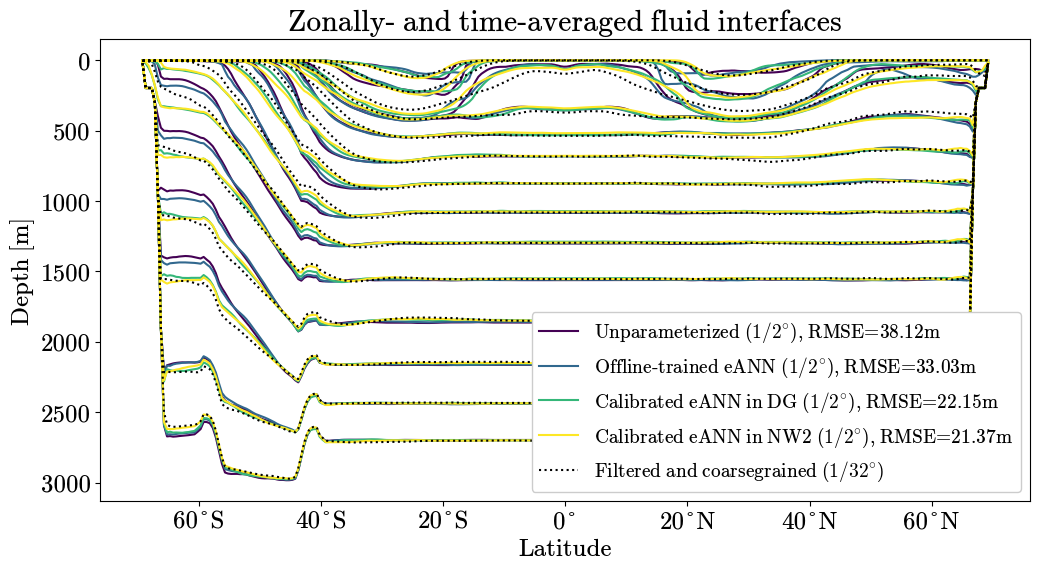

In [ ]:
default_rcParams({'font.size': 18})
plt.figure(figsize=(12,6))

import matplotlib as mpl

# Sorted by decreasing RMSE -> map onto 'winter' (same scheme as the
# gamma-sensitivity figures), with unparameterized at the same color
# as in cells 20 and 22 (winter at 0).
exps   = ['unparameterized', 'eANN_offline_0p5', 'eANN_DG_0.6', 'eANN_NW2']
labels = ['Unparameterized ($1/2^{\circ}$)',
          'Offline-trained eANN ($1/2^{\circ}$)',
          'Calibrated eANN in DG ($1/2^{\circ}$)',
          'Calibrated eANN in NW2 ($1/2^{\circ}$)']
cmap = plt.get_cmap('viridis')
positions = np.linspace(0, 1, len(exps))
colors = [cmap(p) for p in positions]

for exp, lab, c in zip(exps, labels, colors):
    interfaces = interface_dict[exp]
    for zi in range(1,15):
        interfaces.isel(zi=zi).plot(color=c)
    rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth']).isel(zi=slice(1,15))**2))
    plt.plot([], [], color=c, label=f'{lab}, RMSE={rmse:.2f}m')

interfaces = interface_dict['truth']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='k', ls=':')
plt.plot([], [], color='k', ls=':', label='Filtered and coarsegrained ($1/32^{\circ}$)')

#plt.grid()

plt.yticks(np.arange(-3000,500,500), np.arange(3000,-500,-500))
plt.xticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
plt.ylabel('Depth [m]')
plt.legend(loc='lower right', framealpha=1, fontsize=14)
plt.xlabel('Latitude')
plt.title('Zonally- and time-averaged fluid interfaces')
plt.savefig('paper_figures/Figure3-interfaces-review.pdf')

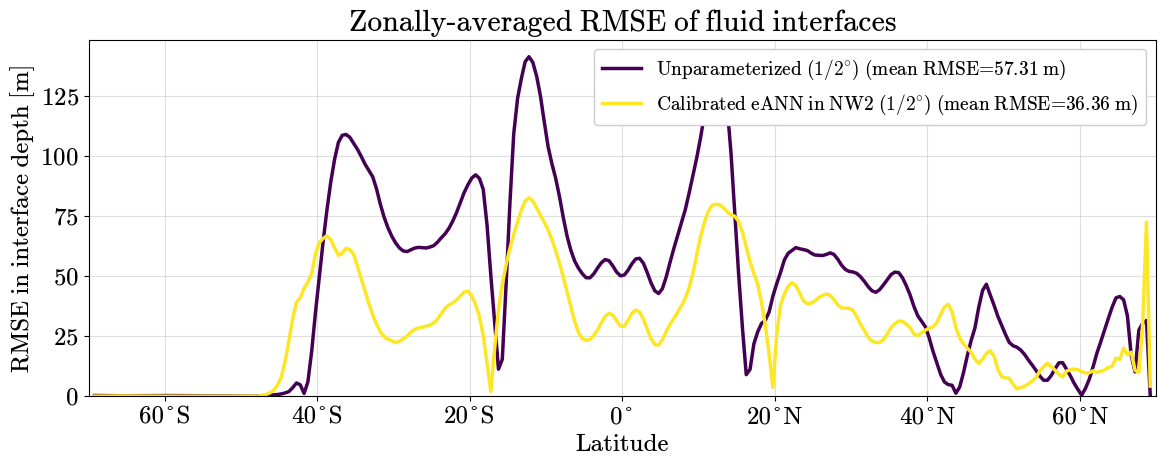

In [ ]:
default_rcParams({'font.size': 18})
plt.figure(figsize=(12, 5))

exps   = ['unparameterized', 'eANN_NW2']
labels = ['Unparameterized ($1/2^{\circ}$)',
          'Calibrated eANN in NW2 ($1/2^{\circ}$)']
cmap = plt.get_cmap('viridis')
positions = np.linspace(0, 1, len(exps))
colors = [cmap(p) for p in positions]

for exp, lab, c in zip(exps, labels, colors):
    interfaces = interface_dict[exp]
    rmse = np.sqrt(((interfaces - interface_dict['truth'])**2).isel(zi=3))
    mean_rmse = float(np.sqrt(np.nanmean(rmse.values**2)))
    rmse.plot(color=c, lw=2.5, label=f'{lab} (mean RMSE={mean_rmse:.2f} m)')

plt.xticks((-60, -40, -20, 0, 20, 40, 60),
           ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
plt.xlim(-70, 70)
plt.ylim(bottom=0)
plt.grid(True, alpha=0.4)
plt.xlabel('Latitude')
plt.ylabel('RMSE in interface depth [m]')
plt.title('Zonally-averaged RMSE of fluid interfaces')
plt.legend(loc='upper right', framealpha=1, fontsize=14)
plt.tight_layout()
plt.savefig('paper_figures/Figure3-interfaces-rmse-review.pdf')

# Shorted calibration

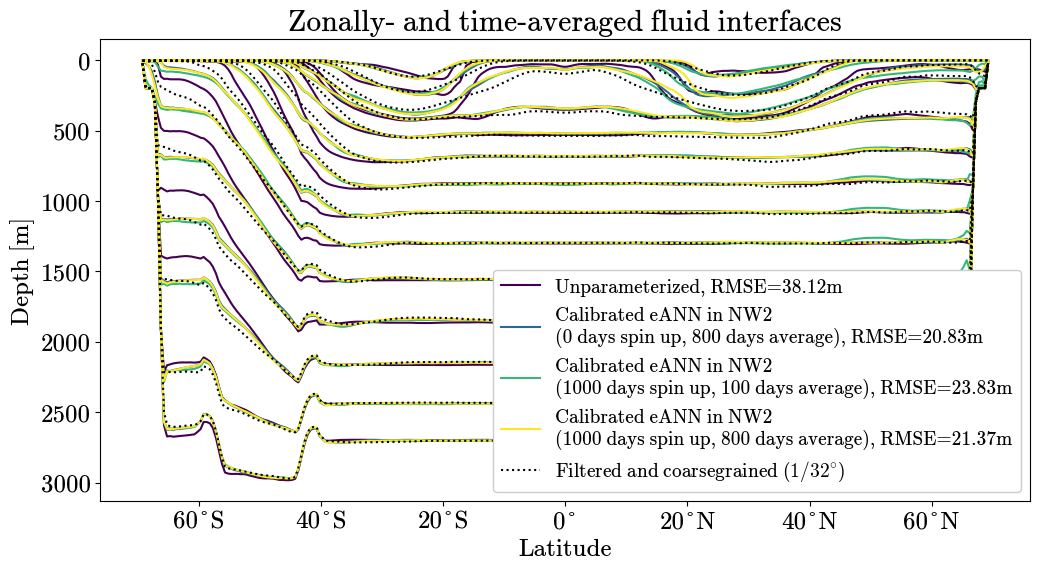

In [ ]:
default_rcParams({'font.size': 18})
plt.figure(figsize=(12,6))

import matplotlib as mpl

# Sorted by decreasing RMSE -> map onto 'winter' (same scheme as the
# gamma-sensitivity figures), with unparameterized at the same color
# as in cells 20 and 22 (winter at 0).
exps   = ['unparameterized', 'eANN_NW2_800', 'eANN_NW2_1100', 'eANN_NW2']
labels = ['Unparameterized',
          'Calibrated eANN in NW2 \n(0 days spin up, 800 days average)',
          'Calibrated eANN in NW2 \n(1000 days spin up, 100 days average)',
          'Calibrated eANN in NW2 \n(1000 days spin up, 800 days average)',
          ]
cmap = plt.get_cmap('viridis')
positions = np.linspace(0, 1, len(exps))
colors = [cmap(p) for p in positions]

for exp, lab, c in zip(exps, labels, colors):
    interfaces = interface_dict[exp]
    for zi in range(1,15):
        interfaces.isel(zi=zi).plot(color=c)
    rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth']).isel(zi=slice(1,15))**2))
    plt.plot([], [], color=c, label=f'{lab}, RMSE={rmse:.2f}m')

interfaces = interface_dict['truth']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='k', ls=':')
plt.plot([], [], color='k', ls=':', label='Filtered and coarsegrained ($1/32^{\circ}$)')

#plt.grid()

plt.yticks(np.arange(-3000,500,500), np.arange(3000,-500,-500))
plt.xticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
plt.ylabel('Depth [m]')
plt.legend(loc='lower right', framealpha=1, fontsize=14)
plt.xlabel('Latitude')
plt.title('Zonally- and time-averaged fluid interfaces')
plt.savefig('paper_figures/NW2-sensitivity-interfaces.pdf')

# Gamma-sensitivity

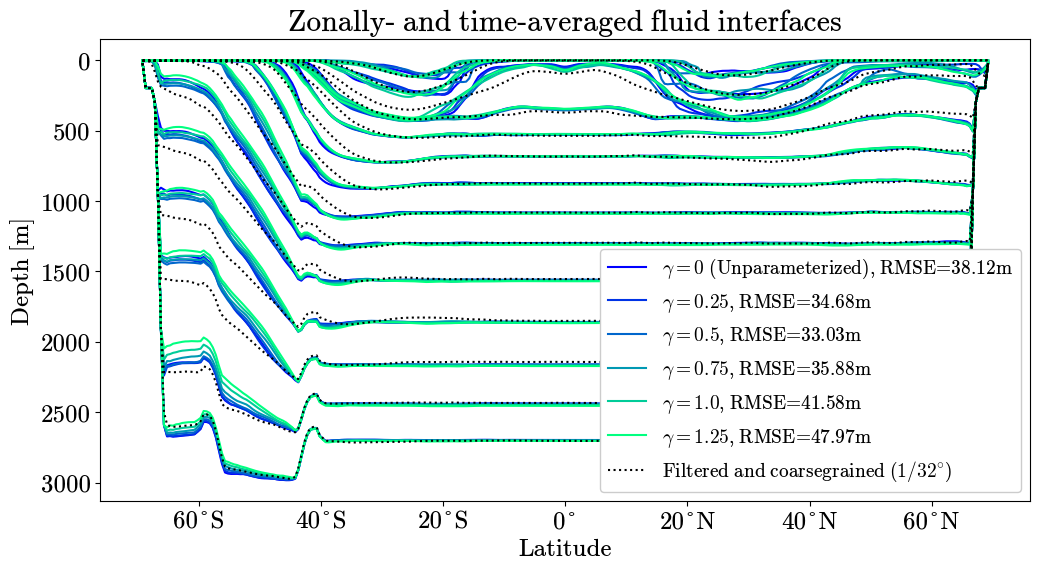

In [ ]:
default_rcParams({'font.size': 18})
plt.figure(figsize=(12,6))

import matplotlib as mpl

gammas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25]
exps   = ['unparameterized', 'eANN_offline_0p25', 'eANN_offline_0p5',
          'eANN_offline_0p75', 'eANN_offline_1p0', 'eANN_offline_1p25']

cmap = plt.get_cmap('winter')
norm = mpl.colors.Normalize(vmin=min(gammas), vmax=max(gammas))
colors = [cmap(norm(g)) for g in gammas]

for g, exp, c in zip(gammas, exps, colors):
    interfaces = interface_dict[exp]
    for zi in range(1,15):
        interfaces.isel(zi=zi).plot(color=c)
    rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth']).isel(zi=slice(1,15))**2))
    if g == 0:
        label = '$\gamma=0$ (Unparameterized), ' + f'RMSE={rmse:.2f}m'
    else:
        label = f'$\gamma={g}$, ' + f'RMSE={rmse:.2f}m'
    plt.plot([], [], color=c, label=label)

interfaces = interface_dict['truth']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='k', ls=':')
plt.plot([], [], color='k', ls=':', label='Filtered and coarsegrained ($1/32^{\circ}$)')

plt.yticks(np.arange(-3000,500,500), np.arange(3000,-500,-500))
plt.xticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
plt.ylabel('Depth [m]')
plt.legend(loc='lower right', framealpha=1, fontsize=14)
plt.xlabel('Latitude')
plt.title('Zonally- and time-averaged fluid interfaces')
plt.savefig('paper_figures/offline-eANN-interfaces-gamma.pdf')

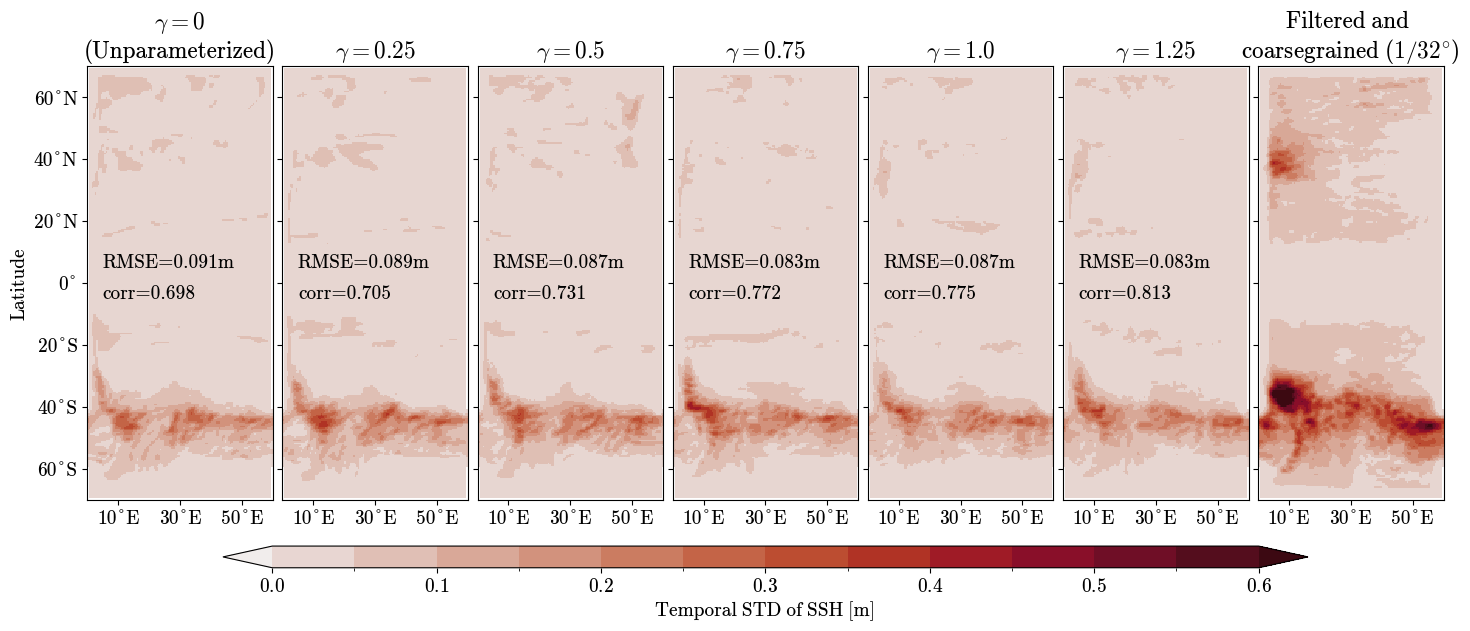

In [ ]:
default_rcParams()
plot_ssh_std(std_dict, ['unparameterized', 'eANN_offline_0p25', 'eANN_offline_0p5', 'eANN_offline_0p75', 'eANN_offline_1p0', 'eANN_offline_1p25', 'truth'],
['$\\gamma=0$ \n(Unparameterized)', '$\\gamma=0.25$', '$\\gamma=0.5$', '$\\gamma=0.75$', '$\\gamma=1.0$', '$\\gamma=1.25$','Filtered and \ncoarsegrained ($1/32^{\circ}$)'], zi=0, ncols=7)
#plt.suptitle('Offline trained eANN with different scaling coefficients ($\\gamma$)', y=0.85)
plt.savefig('paper_figures/offline-eANN-ssh-std-gamma.pdf')

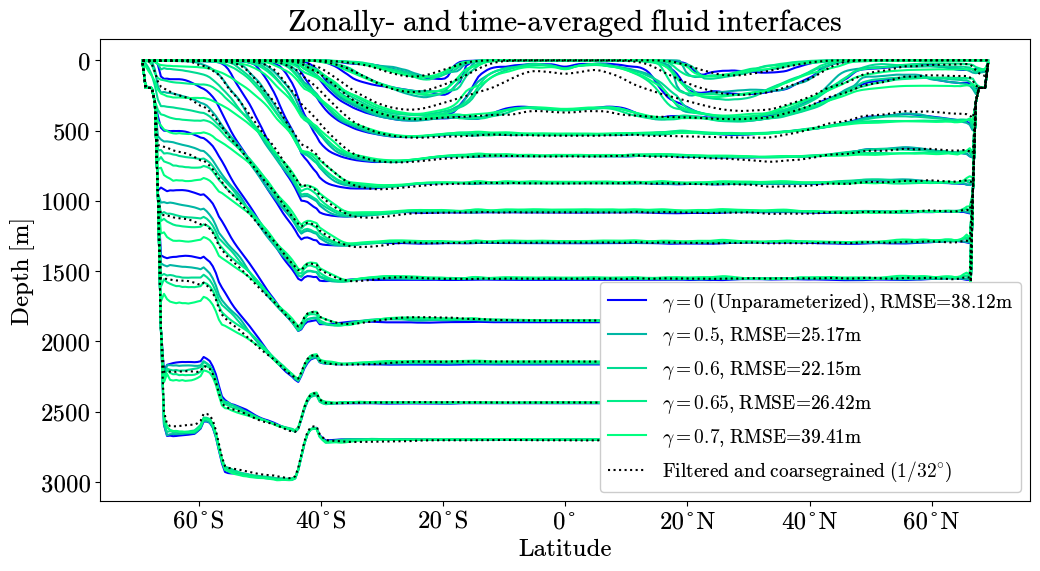

In [ ]:
default_rcParams({'font.size': 18})
plt.figure(figsize=(12,6))

import matplotlib as mpl

gammas = [0.0, 0.5, 0.6, 0.65, 0.7]
exps   = ['unparameterized', 'eANN_DG_0.5', 'eANN_DG_0.6', 'eANN_DG', 'eANN_DG_0.7']

cmap = plt.get_cmap('winter')
norm = mpl.colors.Normalize(vmin=min(gammas), vmax=max(gammas))
colors = [cmap(norm(g)) for g in gammas]

for g, exp, c in zip(gammas, exps, colors):
    interfaces = interface_dict[exp]
    for zi in range(1,15):
        interfaces.isel(zi=zi).plot(color=c)
    rmse = np.sqrt(np.nanmean((interfaces - interface_dict['truth']).isel(zi=slice(1,15))**2))
    if g == 0:
        label = '$\gamma=0$ (Unparameterized), ' + f'RMSE={rmse:.2f}m'
    else:
        label = f'$\gamma={g}$, ' + f'RMSE={rmse:.2f}m'
    plt.plot([], [], color=c, label=label)

interfaces = interface_dict['truth']
for zi in range(1,15):
    interfaces.isel(zi=zi).plot(color='k', ls=':')
plt.plot([], [], color='k', ls=':', label='Filtered and coarsegrained ($1/32^{\circ}$)')

plt.yticks(np.arange(-3000,500,500), np.arange(3000,-500,-500))
plt.xticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'))
plt.ylabel('Depth [m]')
plt.legend(loc='lower right', framealpha=1, fontsize=14)
plt.xlabel('Latitude')
plt.title('Zonally- and time-averaged fluid interfaces')
plt.savefig('paper_figures/DG-eANN-interfaces-gamma.pdf')

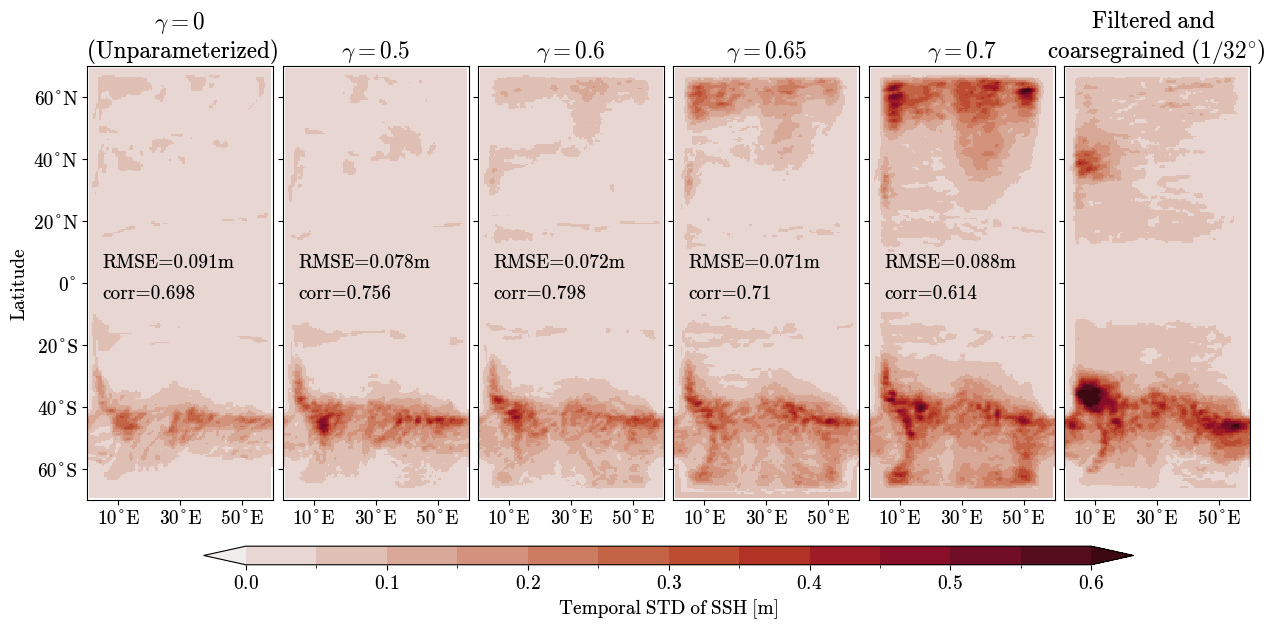

In [ ]:
default_rcParams()
plot_ssh_std(std_dict, ['unparameterized', 'eANN_DG_0.5', 'eANN_DG_0.6', 'eANN_DG', 'eANN_DG_0.7', 'truth'],
['$\\gamma=0$ \n (Unparameterized)', '$\\gamma=0.5$', '$\\gamma=0.6$', '$\\gamma=0.65$', '$\\gamma=0.7$','Filtered and \ncoarsegrained ($1/32^{\circ}$)'], zi=0, ncols=6)
plt.savefig('paper_figures/Figure3-ssh-std-SI-DG-gamma.pdf')

# SSH plot

In [ ]:
from helpers.computational_tools import Lk_error
def plot_ssh_std(self, exps, labels=None, target=None, ncols=4, zi=0, vmax=3.0, cmap=cmocean.cm.amp, show_rmse=True):
    if labels is None:
        labels=exps
    nfig = len(exps)
    ncol = min(ncols,nfig)
    nrows = nfig / ncols
    if nrows > 1:
        nrows = int(np.ceil(nrows))
    else:
        nrows = 1

    if zi == 0:
        levels = np.arange(0,0.65,0.05)
        #levels=np.linspace(-2,1,10)
    else:
        levels = np.arange(0,65,5)

    
    plt.figure(figsize=(2.5*ncols,8))
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for ifig, exp in enumerate(exps):
        plt.subplot(nrows,ncol,ifig+1)
        ssh_std = self[exp].isel(zi=zi)
        
        im = (ssh_std).plot.imshow(levels=levels, cmap=cmap, extend='both', add_colorbar=False)
        
        plt.xticks((10,30,50), ('10°E', '30°E', '50°E'), fontsize=16)
        
        if ifig == 0:
            plt.yticks((-60, -40, -20, 0, 20, 40, 60), ('60°S', '40°S', '20°S', '0°', '20°N', '40°N', '60°N'), fontsize=16)
            plt.ylabel('Latitude', fontsize=16)
        else:
            plt.yticks((-60, -40, -20, 0, 20, 40, 60), ()*7)
            plt.ylabel('')
        plt.title(labels[ifig])
        plt.xlabel('')

        if exp != exps[-1]:
            RMSE = np.sqrt(np.nanmean(((self[exp].isel(zi=zi) - self['truth']).isel(zi=zi))**2))
            corr = float(xr.corr(self[exp].isel(zi=zi),self['truth'].isel(zi=zi)))
            if show_rmse:
                plt.text(5,5,'RMSE='+str(round(RMSE,3))+'m', fontsize=14, color='k')
                plt.text(5,-5,'corr='+str(round(corr,3)), fontsize=14, color='k')
        plt.gca().set_aspect(1)

    cbar = plt.colorbar(im, ax=plt.gcf().axes, label='Temporal STD of SSH [m]', shrink=0.8, pad=0.075, aspect=50, orientation='horizontal')
    cbar.set_label('Temporal STD of SSH [m]', fontsize=16)
    cbar.ax.tick_params(labelsize=18)

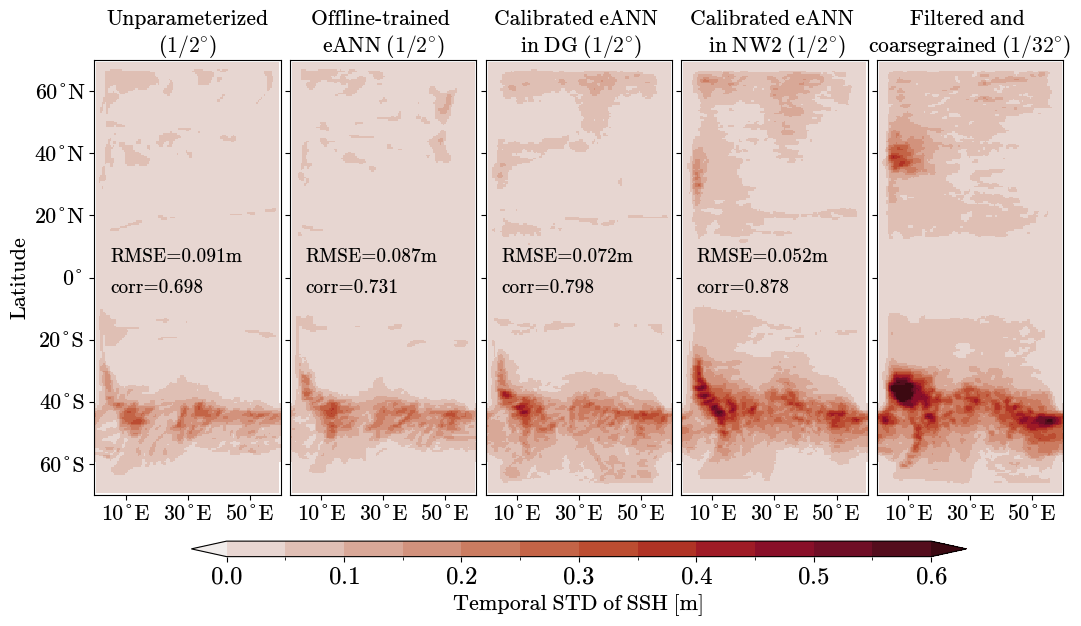

In [ ]:
default_rcParams({'font.size': 13})
plot_ssh_std(std_dict, ['unparameterized', 'eANN_offline_0p5', 'eANN_DG_0.6', 'eANN_NW2', 'truth'],
['Unparameterized\n($1/2^{\circ}$)', 'Offline-trained \neANN ($1/2^{\circ}$)', 'Calibrated eANN \n in DG ($1/2^{\circ}$)', 
'Calibrated eANN \n in NW2 ($1/2^{\circ}$)', 'Filtered and \ncoarsegrained ($1/32^{\circ}$)'], zi=0, ncols=5)
plt.savefig('paper_figures/Figure3-ssh-std-review.pdf')

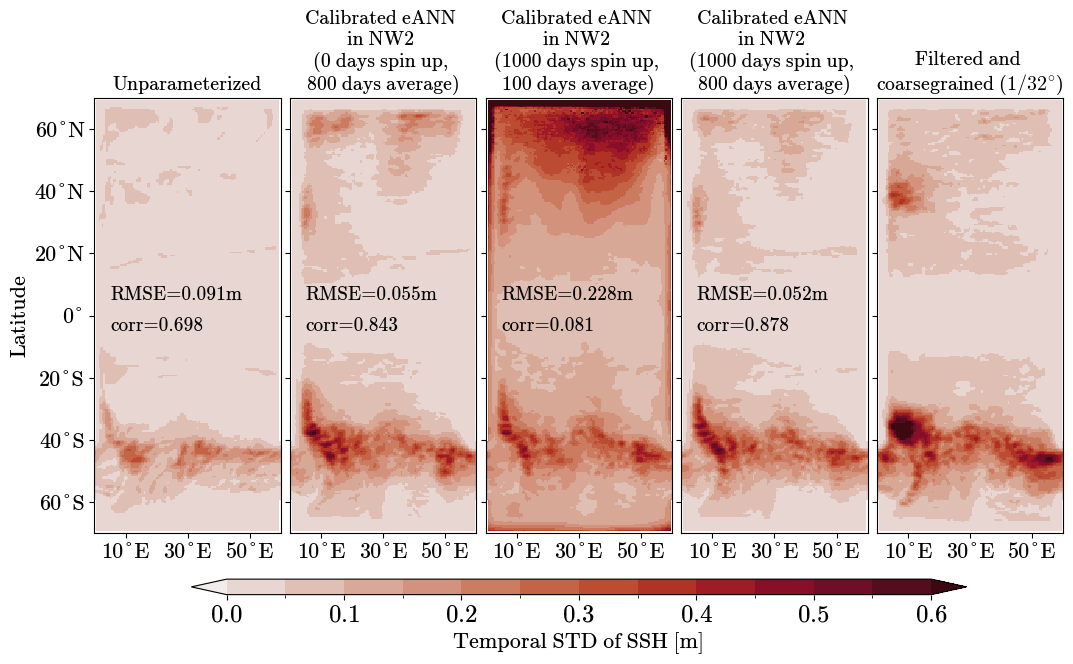

In [ ]:
default_rcParams({'font.size': 12})
plot_ssh_std(std_dict, ['unparameterized', 'eANN_NW2_800', 'eANN_NW2_1100', 'eANN_NW2', 'truth'],
['Unparameterized', 'Calibrated eANN \nin NW2 \n(0 days spin up, \n800 days average)',
'Calibrated eANN \nin NW2 \n(1000 days spin up, \n100 days average)',
'Calibrated eANN \nin NW2 \n(1000 days spin up, \n800 days average)', 
'Filtered and \ncoarsegrained ($1/32^{\circ}$)'], zi=0, ncols=5)
plt.savefig('paper_figures/NW2-sensitivity-ssh-std.pdf')

# Physical interpretation of the calibrated neural networks

In [1]:
import xarray as xr
import sys
sys.path.append('/home/pp2681/ANN-momentum-mesoscale/src/training-on-CM2.6')
from helpers.selectors import *
from helpers.cm26 import read_datasets
from helpers.plot_helpers import default_rcParams

In [2]:
ds = read_datasets(['test'], [4], subfilter='subfilter', FGR=3)
dataset = ds['test-4'].select2d(zl=0,time=0).data

Reading from folder /scratch/pp2681/CM26_datasets/ocean3d/subfilter/FGR3/factor-4


In [3]:
def read_skill(exp='subfilter/FGR3/EXP1', base_path='/scratch/pp2681/mom6/CM26_ML_models/ocean3d/'):

    data = xr.open_dataset(f'{base_path}/{exp}/skill-test/factor-4.nc', chunks={'zl':1})
    data['zl'] = -data['zl']
    data['Tdd_pred'] = (data['Txx_pred'] - data['Tyy_pred']) * 0.5
    data['Ttr_pred'] = (data['Txx_pred'] + data['Tyy_pred']) * 0.5
    data['Tdd'] = (data['Txx'] - data['Tyy']) * 0.5
    data['Ttr'] = (data['Txx'] + data['Tyy']) * 0.5

    # Positive values is backscatter
    data['SGS_back_trace'] = - data['Ttr'] * data['div']
    data['SGS_back_along'] = - (data['Tdd'] * data['sh_xx'] + data['Txy'] * data['sh_xy_h'])
    # Here the sign notation is arbitrary
    data['SGS_back_cross'] = - (data['Tdd'] * data['sh_xy_h'] - data['Txy'] * data['sh_xx'])

    data['SGS_back_trace_pred'] = - data['Ttr_pred'] * data['div']
    data['SGS_back_along_pred'] = - (data['Tdd_pred'] * data['sh_xx'] + data['Txy_pred'] * data['sh_xy_h'])
    data['SGS_back_cross_pred'] = - (data['Tdd_pred'] * data['sh_xy_h'] - data['Txy_pred'] * data['sh_xx'])

    return data

In [4]:
ANN_offline = read_skill(f'subfilter/FGR3/EXP1')
eANN_offline = read_skill(f'subfilter/FGR3/equivariant/learning_rate/N8-forcing-fluxes/0.05')
eANN_NW2 = read_skill(f'subfilter/FGR3/equivariant/learning_rate/N8-forcing-fluxes/0.05-calibrated-NW2-gprime_n-it3-ens-200')
eANN_DG = read_skill(f'subfilter/FGR3/equivariant/learning_rate/N8-forcing-fluxes/0.05-calibrated-DG-gprime_2-it5-ens-100')
ZB = read_skill(f'subfilter-large/FGR3/ZB20/ZB-SCALING-0.5/')

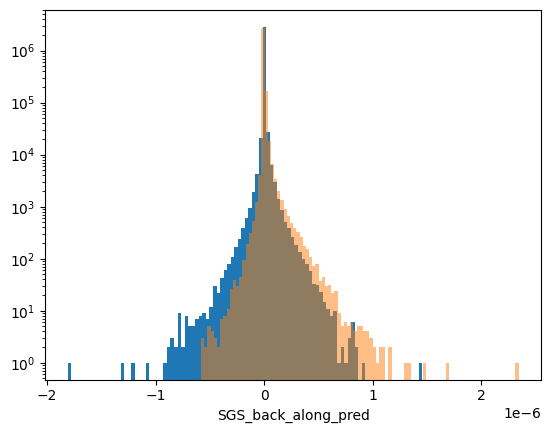

In [56]:
%matplotlib inline
eANN_offline['SGS_back_along_pred'].plot.hist(bins=100)
eANN_NW2['SGS_back_along_pred'].plot.hist(bins=100, alpha=0.5)
plt.yscale('log')
plt.show()

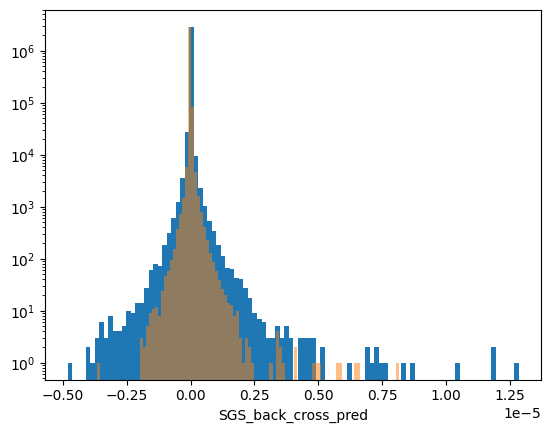

In [57]:
%matplotlib inline
eANN_offline['SGS_back_cross_pred'].plot.hist(bins=100)
eANN_NW2['SGS_back_cross_pred'].plot.hist(bins=100, alpha=0.5)
plt.yscale('log')
plt.show()

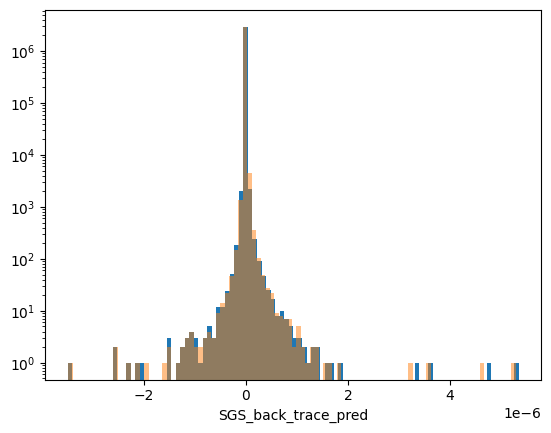

In [58]:
%matplotlib inline
eANN_offline['SGS_back_trace_pred'].plot.hist(bins=100)
eANN_NW2['SGS_back_trace_pred'].plot.hist(bins=100, alpha=0.5)
plt.yscale('log')
plt.show()

## Testing decomposition on ZB model

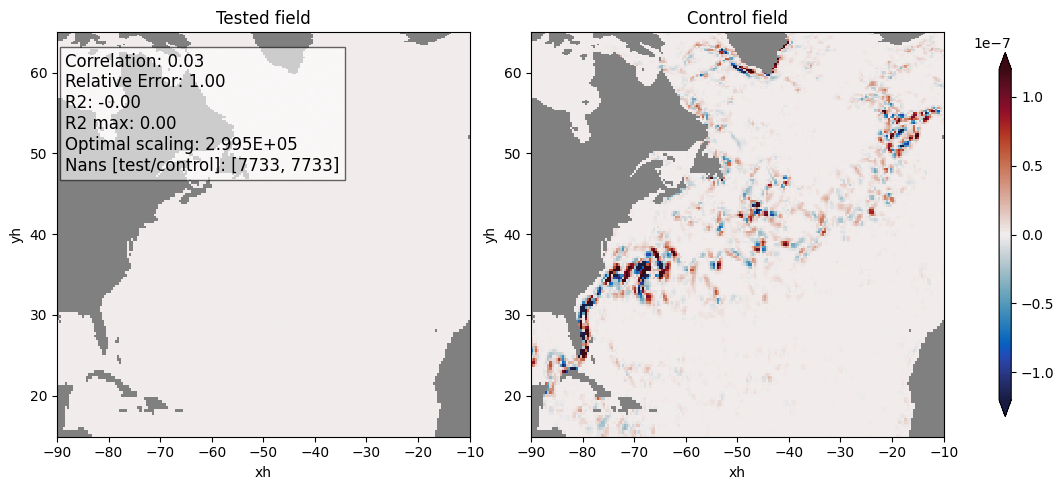

In [59]:
compare(ZB['SGS_back_along_pred'], ZB['SGS_back_along'], vmin=-1.2e-7, vmax=1.2e-7)
plt.show()

In [61]:
compare(ZB['SGS_back_trace_pred'], ZB['SGS_back_trace'], vmin=-1.2e-7, vmax=1.2e-7)

array([<Axes: title={'center': 'Tested field'}, xlabel='xh', ylabel='yh'>,
       <Axes: title={'center': 'Control field'}, xlabel='xh', ylabel='yh'>],
      dtype=object)

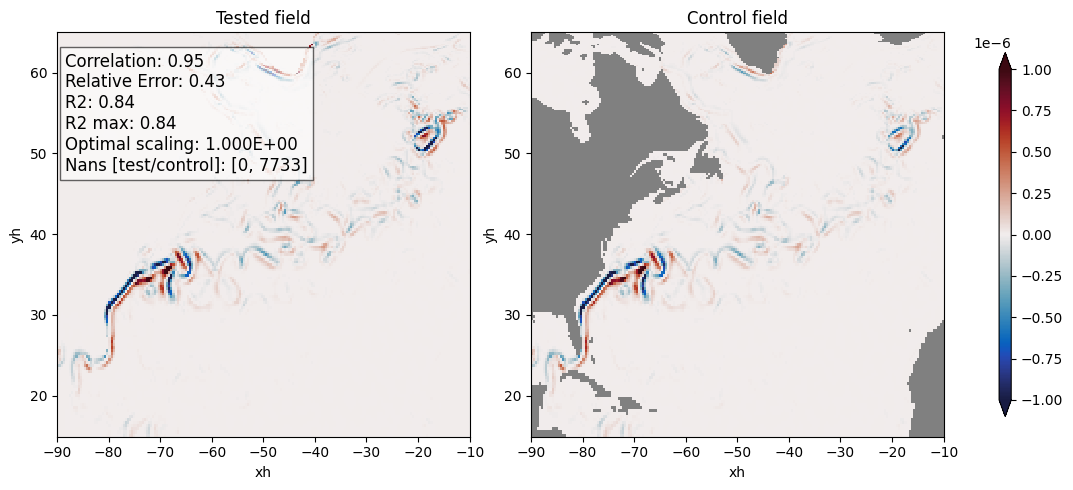

In [65]:
compare(-6.984e+8 * dataset['shear_mag']**2 * dataset['vort_xy_h'], ZB['SGS_back_cross_pred'].isel(zl=0), vmin=-1e-6, vmax=1e-6)
plt.show()

# Final figure

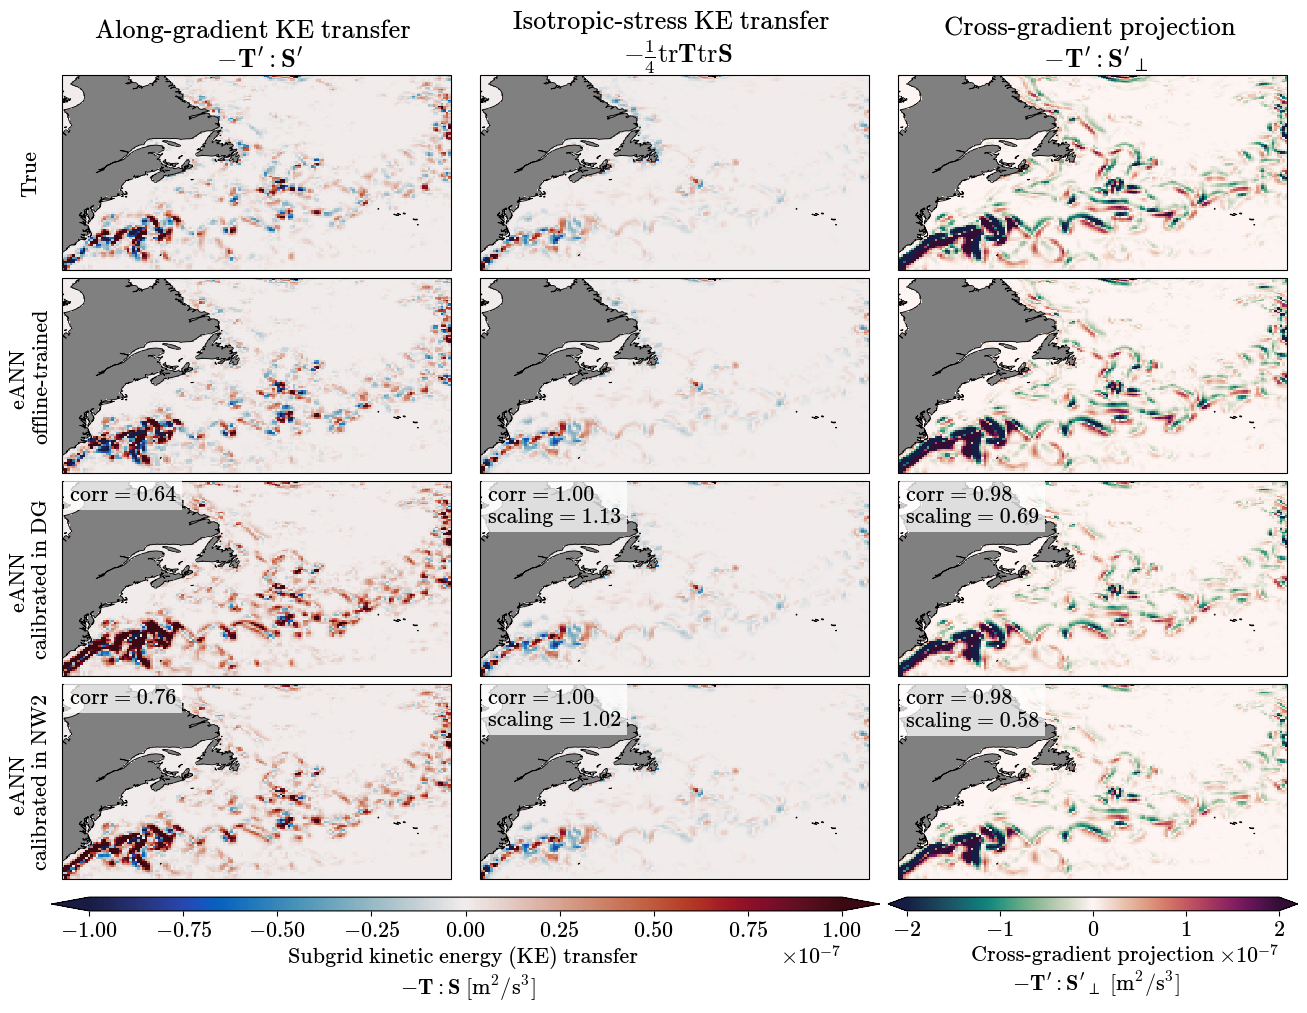

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature

default_rcParams({'font.size': 16})

# Column order: along, trace (shares colorbar with along), cross
components = ['along', 'trace', 'cross']

# along and trace share the same diverging cmap; cross has its own.
cmaps = {
    'along': cmocean.cm.balance,  # blue / white / red
    'trace': cmocean.cm.balance,  # same as along (shared colorbar)
    'cross': cmocean.cm.curl,     # teal / white / magenta
}

rows = [
    ('True',         eANN_offline, 'SGS_back_{c}'),
    ('eANN \noffline-trained', eANN_offline, 'SGS_back_{c}_pred'),
    ('eANN \ncalibrated in DG',      eANN_DG,      'SGS_back_{c}_pred'),
    ('eANN \ncalibrated in NW2',     eANN_NW2,     'SGS_back_{c}_pred'),
]

zl_sel = 0

proj = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(
    4, 3, figsize=(13, 10),
    constrained_layout=True,
    subplot_kw={'projection': proj},
)

vmax_dict = {'along': 1e-7, 'trace': 1e-7, 'cross': 2e-7}
title={'along': 'Along-gradient KE transfer \n $-\\mathbf{T}\':\\mathbf{S}\'$', 
       'trace': 'Isotropic-stress KE transfer \n $-\\frac{1}{4}\\mathrm{tr}\\mathbf{T} \\mathrm{tr}\\mathbf{S}$',
       'cross': 'Cross-gradient projection \n $-\\mathbf{T}\':\\mathbf{S}\'_{\\perp}$'}


last_im_per_col = {}

for j, comp in enumerate(components):
    cmap = cmaps[comp]
    cmap.set_bad('gray')
    vmax = vmax_dict[comp]

    field_ref = select_Gulf(
        eANN_offline[f'SGS_back_{comp}_pred'].isel(zl=zl_sel)
    ).compute()

    last_im = None
    for i, (label, ds_i, tmpl) in enumerate(rows):
        ax = axes[i, j]
        field = select_Gulf(ds_i[tmpl.format(c=comp)].isel(zl=zl_sel)).compute()
        last_im = field.plot(
            ax=ax, vmin=-vmax, vmax=vmax, cmap=cmap,
            add_colorbar=False, transform=data_crs,
        )

        ax.coastlines(resolution='50m', linewidth=0.6, color='k')
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)

        ax.set_title(title[comp] if i == 0 else '')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.text(-0.08, 0.5, label, transform=ax.transAxes,
                    ha='center', va='center', rotation=90, fontsize=16)

        if i >= 2:
            tested = field
            control = field_ref
            corr = float(xr.corr(tested, control))
            denom = float((tested * tested).mean())
            alpha = float((tested * control).mean() / denom) if denom > 0 else np.nan
            if j > 0:
                ax.text(
                    0.02, 0.98,
                    f'corr = {corr:.2f}\n' + r'scaling = ' + f'{1./alpha:.2f}',
                    transform=ax.transAxes, ha='left', va='top', fontsize=16,
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'),
                )
            else:
                ax.text(
                    0.02, 0.98,
                    f'corr = {corr:.2f}',
                    transform=ax.transAxes, ha='left', va='top', fontsize=16,
                    bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'),
                )

    last_im_per_col[j] = last_im

# Shared colorbar for columns 0 (along) and 1 (trace)
fig.colorbar(last_im_per_col[0], ax=axes[:, 0:2].ravel().tolist(),
             location='bottom', shrink=1, aspect=60, extend='both', pad=0.02,
             label='Subgrid kinetic energy (KE) transfer \n $-\\mathbf{T}:\\mathbf{S}$ [m$^2$/s$^3$]')

# Separate colorbar for column 2 (cross)
fig.colorbar(last_im_per_col[2], ax=axes[:, 2].tolist(),
             location='bottom', shrink=1, aspect=30, extend='both', pad=0.02,
             label='Cross-gradient projection\n $-\\mathbf{T}\':\\mathbf{S}\'_{\\perp}$ [m$^2$/s$^3$]')

plt.savefig('paper_figures/offline_skill_maps.png', dpi=200, bbox_inches='tight')
plt.show()